# AnnData × AnnNet

Kang 2018 (24,673 PBMCs, ctrl vs IFN-β, 8 donors) as the expression object. OmniPath (8,791 nodes, 85,217 directed signed edges) as the topology object. Each section poses a question that neither object can answer alone.

- Load expression (AnnData) and signaling topology (AnnNet) independently
- Transfer per-gene statistics onto network vertices
- Store 8 donor expression profiles as layers on one shared topology
- Define condition-specific subnetworks via slice algebra
- Query directed pathway reachability under per-group expression masks
- Compare topology-constrained vs gene-set pathway scoring
- Use topology scores to augment cell embeddings and identify downstream DEGs
- Export to PyG and serialize both objects
- Demonstrate hyperedge representation of stoichiometric reactions

## 0 — Setup

In [1]:
import gc
import logging
import os
import sys
import warnings
from collections import deque
from itertools import combinations

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)
os.makedirs(os.environ["NUMBA_CACHE_DIR"], exist_ok=True)

sys.path.insert(0, os.path.abspath(".."))

warnings.filterwarnings("ignore", category=FutureWarning, module=r"scanpy\..*")
warnings.filterwarnings("ignore", category=FutureWarning, module=r"anndata\..*")

import anndata as ad
import annnet
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pertpy as pt
import polars as pl
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from annnet import AnnNet, read_omnipath, to_pyg

print(f"annnet {getattr(annnet, '__version__', 'unknown')} | anndata {ad.__version__} | scanpy {sc.__version__} | polars {pl.__version__}")

/home/l1boll/miniconda3/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


annnet 0.1.0 | anndata 0.12.10 | scanpy 1.11.5 | polars 1.35.2


/tmp/ipykernel_4674/523031983.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print(f"annnet {getattr(annnet, '__version__', 'unknown')} | anndata {ad.__version__} | scanpy {sc.__version__} | polars {pl.__version__}")
/tmp/ipykernel_4674/523031983.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"annnet {getattr(annnet, '__version__', 'unknown')} | anndata {ad.__version__} | scanpy {sc.__version__} | polars {pl.__version__}")


In [2]:
def mean_and_var(X):
    if sp.issparse(X):
        mean = np.asarray(X.mean(axis=0)).ravel()
        mean_sq = np.asarray(X.power(2).mean(axis=0)).ravel()
    else:
        mean = np.asarray(X.mean(axis=0)).ravel()
        mean_sq = np.asarray(np.square(X).mean(axis=0)).ravel()
    return mean.astype(np.float64), (mean_sq - np.square(mean)).astype(np.float64)


def expressed_genes(adata_obj, mask, fraction=0.30):
    X_sub = adata_obj[mask].X
    mean = np.asarray(X_sub.mean(axis=0)).ravel() if sp.issparse(X_sub) else np.asarray(X_sub.mean(axis=0)).ravel()
    pos = mean[mean > 0]
    if pos.size == 0:
        return set(), mean, float("nan")
    threshold = float(np.quantile(pos, 1.0 - fraction))
    return set(adata_obj.var_names[mean >= threshold].tolist()), mean.astype(np.float64), threshold


def bfs(adjacency, src, tgt, allowed=None, max_depth=6):
    if allowed is not None and (src not in allowed or tgt not in allowed):
        return False, []
    queue = deque([(src, [src])])
    visited = {src}
    while queue:
        node, path = queue.popleft()
        if len(path) > max_depth:
            continue
        for nb in adjacency.get(node, []):
            if allowed is not None and nb not in allowed:
                continue
            if nb == tgt:
                return True, path + [nb]
            if nb not in visited:
                visited.add(nb)
                queue.append((nb, path + [nb]))
    return False, []


def deep_sizeof(obj, seen=None):
    if seen is None:
        seen = set()
    if id(obj) in seen:
        return 0
    seen.add(id(obj))
    size = sys.getsizeof(obj)
    if isinstance(obj, dict):
        size += sum(deep_sizeof(k, seen) + deep_sizeof(v, seen) for k, v in obj.items())
    elif isinstance(obj, (list, tuple, set, frozenset, deque)):
        size += sum(deep_sizeof(v, seen) for v in obj)
    elif hasattr(obj, "__dict__"):
        size += deep_sizeof(vars(obj), seen)
    return size

## 1 — Independent Construction

AnnData and AnnNet are loaded separately. Neither object knows about the other until Section 2.

In [3]:
adata = pt.data.kang_2018()
adata.obs["condition"] = adata.obs["label"].astype(str)
adata.obs["leiden"]    = adata.obs["cell_type"].astype(str)
adata.obs["donor"]     = adata.obs["replicate"].astype(str)

print(f"{adata.n_obs} cells × {adata.n_vars} genes")
print(f"conditions: {adata.obs['condition'].value_counts().to_dict()}")
print(f"cell types: {adata.obs['leiden'].nunique()}, donors: {adata.obs['donor'].nunique()}")

24673 cells × 15706 genes
conditions: {'stim': 12358, 'ctrl': 12315}
cell types: 8, donors: 8


In [4]:
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)

In [5]:
root_logger = logging.getLogger()
old_level = root_logger.level
root_logger.setLevel(logging.ERROR)
try:
    G = read_omnipath(
        dataset="omnipath",
        query={"organism": "human", "genesymbols": True},
        source_col="source_genesymbol",
        target_col="target_genesymbol",
        edge_attr_cols=[
            "is_stimulation", "is_inhibition", "consensus_direction",
            "consensus_stimulation", "consensus_inhibition",
            "n_sources", "n_references", "sources",
        ],
        slice="omnipath_pkn",
    )
finally:
    root_logger.setLevel(old_level)

print(f"{G.num_vertices} vertices × {G.num_edges} edges")
print(G.edge_attributes.select(["edge_id", "consensus_stimulation", "n_sources"]).head(3))

[timing] fetch/receive df:     4.518s
[timing] column resolution:    0.0153s
         source='source_genesymbol'  target='target_genesymbol'  directed='is_directed'
         edge_attr_cols (8): ['is_stimulation', 'is_inhibition', 'consensus_direction', 'consensus_stimulation', 'consensus_inhibition', 'n_sources', 'n_references', 'sources']
[timing] AnnNet init:          0.007s  (pre-sized n=85217 e=85217)
[timing] _to_dicts:            0.391s  (85217 rows)
[timing] bulk list build:      0.496s  (85217 edges)
[timing] add_edges_bulk:       3.127s
         vertices=8791  edges=85217
[vertex annotations] loading from cache: /home/l1boll/.cache/annnet/omnipath_annotations.tsv.gz
[vertex annotations] loaded in 28.0s  shape=(32164039, 7)
[vertex annotations] loaded  shape=(8791, 254)
8791 vertices × 85217 edges
shape: (3, 3)
┌─────────┬───────────────────────┬───────────┐
│ edge_id ┆ consensus_stimulation ┆ n_sources │
│ ---     ┆ ---                   ┆ ---       │
│ str     ┆ bool         

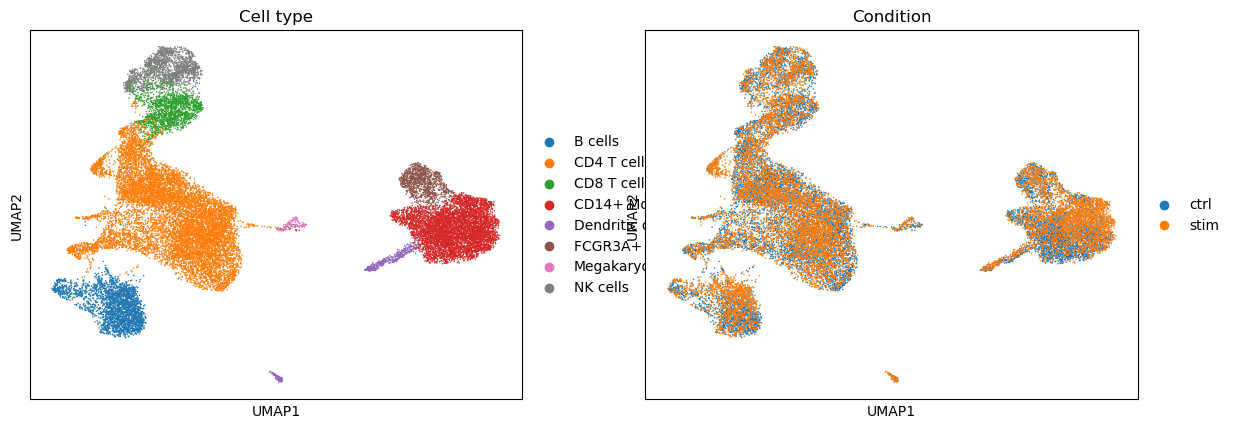

In [6]:
sc.pl.umap(adata, color=["leiden", "condition"], ncols=2,
           title=["Cell type", "Condition"], show=False)
plt.savefig("fig_section1.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 — Annotation Transfer

Per-gene expression statistics computed from AnnData are written onto AnnNet vertices. After this, topology and expression statistics live in one object.

In [7]:
mean_expr, var_expr = mean_and_var(adata.X)

ctrl_mask = (adata.obs["condition"] == "ctrl").to_numpy()
stim_mask = (adata.obs["condition"] == "stim").to_numpy()
ctrl_mean, _ = mean_and_var(adata[ctrl_mask].X)
stim_mean, _ = mean_and_var(adata[stim_mask].X)

network_genes = set(G.vertices())
shared_genes  = network_genes & set(adata.var_names.tolist())
print(f"shared genes: {len(shared_genes)} / {len(network_genes)} network vertices")

gene_stats_df = pl.DataFrame({
    "vertex_id":      adata.var_names.tolist(),
    "mean_expr":      mean_expr.tolist(),
    "var_expr":       var_expr.tolist(),
    "delta_stim_ctrl": (stim_mean - ctrl_mean).tolist(),
})

shared_updates = {
    row["vertex_id"]: {k: row[k] for k in ("mean_expr", "var_expr", "delta_stim_ctrl")}
    for row in gene_stats_df.filter(pl.col("vertex_id").is_in(shared_genes)).iter_rows(named=True)
}
G.set_vertex_attrs_bulk(shared_updates)

degree_updates = {
    v: {
        "out_degree": float(len(G._src_to_edges.get(v, []))),  # INTERNAL API — raise issue for public equivalent
        "in_degree":  float(len(G._tgt_to_edges.get(v, []))),  # INTERNAL API — raise issue for public equivalent
    }
    for v in G.vertices()
}
G.set_vertex_attrs_bulk(degree_updates)

print(
    G.vertex_attributes
    .filter(pl.col("vertex_id").is_in(sorted(list(shared_genes))[:10]))
    .select(["vertex_id", "mean_expr", "var_expr", "delta_stim_ctrl", "out_degree", "in_degree"])
    .head(5)
)

shared genes: 5551 / 8791 network vertices
shape: (5, 6)
┌───────────┬───────────┬──────────┬─────────────────┬────────────┬───────────┐
│ vertex_id ┆ mean_expr ┆ var_expr ┆ delta_stim_ctrl ┆ out_degree ┆ in_degree │
│ ---       ┆ ---       ┆ ---      ┆ ---             ┆ ---        ┆ ---       │
│ str       ┆ f64       ┆ f64      ┆ f64             ┆ f64        ┆ f64       │
╞═══════════╪═══════════╪══════════╪═════════════════╪════════════╪═══════════╡
│ ABCB1     ┆ null      ┆ null     ┆ null            ┆ 0.0        ┆ 11.0      │
│ A1BG      ┆ null      ┆ null     ┆ null            ┆ 0.0        ┆ 2.0       │
│ ABCC1     ┆ null      ┆ null     ┆ null            ┆ 0.0        ┆ 2.0       │
│ AATK      ┆ null      ┆ null     ┆ null            ┆ 2.0        ┆ 1.0       │
│ ABCA1     ┆ null      ┆ null     ┆ null            ┆ 2.0        ┆ 16.0      │
└───────────┴───────────┴──────────┴─────────────────┴────────────┴───────────┘


## 3 — Donor Layers

Eight donor expression profiles stored as layers on one shared topology. The incidence matrix is not copied — each layer is a membership set over the same structure.

*With eight separate NetworkX graphs there is no structural guarantee that node `STAT1` in donor 1 refers to the same vertex as `STAT1` in donor 7. Here it is the same vertex by construction.*

In [8]:
donor_ids = sorted(adata.obs["donor"].unique().tolist())
G.set_aspects(["donor"], {"donor": donor_ids})
G.layers.set_aspect_attrs("donor", dataset="Kang 2018", field="replicate")

donor_slice_ids  = []
donor_gene_sets  = {}

for donor_id in donor_ids:
    mask = (adata.obs["donor"] == donor_id).to_numpy()
    genes, _, threshold = expressed_genes(adata, mask, fraction=0.30)
    genes = genes & network_genes
    donor_gene_sets[donor_id] = genes

    layer_tuple = (donor_id,)
    G.layers.set_layer_attrs(layer_tuple, n_cells=int(mask.sum()), threshold=float(threshold))
    for gene in genes:
        G.add_presence(gene, layer_tuple)

    slice_id = f"donor_{donor_id}"
    donor_slice_ids.append(slice_id)
    G.layers.to_slice(layer_tuple, slice_id=slice_id, n_cells=int(mask.sum()), threshold=float(threshold))

print(f"{len(donor_ids)} donor layers")
print("layer tuples:", G.layers.layer_tuples())

8 donor layers
layer tuples: [('patient_101',), ('patient_1015',), ('patient_1016',), ('patient_1039',), ('patient_107',), ('patient_1244',), ('patient_1256',), ('patient_1488',)]


In [9]:
consensus_result = {"vertices": set(), "edges": set()}
for combo in combinations(donor_slice_ids, 5):
    r = G.slices.intersect(list(combo))
    consensus_result["vertices"].update(r["vertices"])
    consensus_result["edges"].update(r["edges"])

G.create_slice_from_operation(
    "consensus_5of8",
    consensus_result,
    rule="expressed in >=5/8 donors",
)

for sid in donor_slice_ids:
    print(f"  {sid}: {len(G.slices.vertices(sid))} genes")
print(f"consensus (>=5/8 donors): {len(G.slices.vertices('consensus_5of8'))} genes")

consensus_hubs = sorted(
    G.slices.vertices("consensus_5of8"),
    key=lambda g: len(G._src_to_edges.get(g, [])),  # INTERNAL API — raise issue for public equivalent
    reverse=True,
)[:10]
print("\ntop 10 consensus hubs by out-degree:")
for g in consensus_hubs:
    print(f"  {g}: {len(G._src_to_edges.get(g, []))}")  # INTERNAL API — raise issue for public equivalent

  donor_patient_101: 1954 genes
  donor_patient_1015: 2085 genes
  donor_patient_1016: 1979 genes
  donor_patient_1039: 1820 genes
  donor_patient_107: 1846 genes
  donor_patient_1244: 1983 genes
  donor_patient_1256: 2031 genes
  donor_patient_1488: 2011 genes
consensus (>=5/8 donors): 1926 genes

top 10 consensus hubs by out-degree:
  CSNK2A1: 334
  MAPK1: 313
  ATM: 257
  PRKDC: 205
  FYN: 167
  PPP2CA: 127
  PRKCD: 126
  LYN: 117
  LCK: 111
  CSNK1A1: 110


## 4 — Condition Slices

`expressed_ctrl` and `expressed_stim` are named subsets of the shared topology. Derived slices (`gained_stim`, `lost_stim`, `stable`) are set-algebra operations on those subsets — no graph copies.

In [10]:
ctrl_genes, _, ctrl_thresh = expressed_genes(adata, ctrl_mask, fraction=0.30)
stim_genes, _, stim_thresh = expressed_genes(adata, stim_mask, fraction=0.30)
ctrl_genes &= network_genes
stim_genes &= network_genes

G.create_slice_from_operation("expressed_ctrl", {"vertices": ctrl_genes, "edges": set()}, condition="ctrl", threshold=float(ctrl_thresh))
G.create_slice_from_operation("expressed_stim", {"vertices": stim_genes, "edges": set()}, condition="stim", threshold=float(stim_thresh))
G.slices.difference_create("expressed_stim", "expressed_ctrl", "gained_stim")
G.slices.difference_create("expressed_ctrl", "expressed_stim", "lost_stim")
G.slices.intersect_create(["expressed_ctrl", "expressed_stim"], "stable")

for name in ("expressed_ctrl", "expressed_stim", "gained_stim", "lost_stim", "stable"):
    print(f"  {name}: {len(G.slices.vertices(name))}")

gained_hubs = sorted(
    G.slices.vertices("gained_stim"),
    key=lambda g: len(G._src_to_edges.get(g, [])),  # INTERNAL API — raise issue for public equivalent
    reverse=True,
)[:10]
print("\ntop 10 gained_stim hubs:")
for g in gained_hubs:
    print(f"  {g}: {len(G._src_to_edges.get(g, []))}")  # INTERNAL API — raise issue for public equivalent

  expressed_ctrl: 2158
  expressed_stim: 2153
  gained_stim: 175
  lost_stim: 180
  stable: 1978

top 10 gained_stim hubs:
  PRKAA1: 102
  LAG3: 60
  JAK2: 59
  TRAF6: 41
  CREBBP: 38
  RPS6KA5: 30
  PTK2B: 30
  IKBKE: 27
  ABL2: 24
  TNF: 20


## 5 — BFS Reachability on Expressed Subgraphs

For each condition and each condition × cell-type group: is a receptor-to-TF route intact once the network is masked to expressed genes? This query requires both the directed graph and per-cell expression state simultaneously.

In [11]:
sign_lookup = {}
for row in G.edge_attributes.select(["edge_id", "consensus_stimulation", "consensus_inhibition"]).iter_rows(named=True):
    s = 1.0 if row["consensus_stimulation"] else (-1.0 if row["consensus_inhibition"] else 0.0)
    if s != 0.0:
        sign_lookup[row["edge_id"]] = s

adj = {}
for eid, (src, tgt, _) in G.edge_definitions.items():
    if src is None or tgt is None:
        continue
    if sign_lookup.get(eid, 0.0) > 0:
        adj.setdefault(src, []).append(tgt)

SIGNAL_AXES = {
    "IL2R→STAT5":  ("IL2RA",  "STAT5A"),
    "TCR→NFATC1":  ("CD3D",   "NFATC1"),
    "BCR→NFKB1":   ("CD79A",  "NFKB1"),
    "TNF→RELA":    ("TNF",    "RELA"),
    "IFNG→STAT1":  ("IFNGR1", "STAT1"),
    "TLR4→IRF3":   ("TLR4",   "IRF3"),
    "IL6R→STAT3":  ("IL6R",   "STAT3"),
    "FAS→CASP3":   ("FAS",    "CASP3"),
}

axis_paths = {}
for name, (src, tgt) in SIGNAL_AXES.items():
    ok, path = bfs(adj, src, tgt, max_depth=6)
    if ok:
        axis_paths[name] = path
        print(f"  {name}: {' → '.join(path)}")

print(f"\n{len(axis_paths)}/8 axes have network paths")

  TNF→RELA: TNF → TNFRSF1B → TRAF2 → MAP3K14 → RELA
  IFNG→STAT1: IFNGR1 → JAK1 → STAT1
  TLR4→IRF3: TLR4 → TICAM1 → TBK1 → IRF3
  IL6R→STAT3: IL6R → JAK2 → STAT3
  FAS→CASP3: FAS → CASP8AP2 → CASP8 → CASP3

5/8 axes have network paths


In [12]:
for cond, sid in [("ctrl", "expressed_ctrl"), ("stim", "expressed_stim")]:
    expressed = set(G.slices.vertices(sid))
    for name, (src, tgt) in SIGNAL_AXES.items():
        ok, path = bfs(adj, src, tgt, allowed=expressed, max_depth=6)
        print(f"  [{cond}] {name}: {'active — ' + ' → '.join(path) if ok else 'broken'}")
    print()

  [ctrl] IL2R→STAT5: broken
  [ctrl] TCR→NFATC1: broken
  [ctrl] BCR→NFKB1: broken
  [ctrl] TNF→RELA: broken
  [ctrl] IFNG→STAT1: active — IFNGR1 → JAK1 → STAT1
  [ctrl] TLR4→IRF3: broken
  [ctrl] IL6R→STAT3: broken
  [ctrl] FAS→CASP3: broken

  [stim] IL2R→STAT5: broken
  [stim] TCR→NFATC1: broken
  [stim] BCR→NFKB1: broken
  [stim] TNF→RELA: active — TNF → TNFRSF1A → RIPK1 → TRAF6 → CSNK2A1 → RELA
  [stim] IFNG→STAT1: active — IFNGR1 → JAK1 → STAT1
  [stim] TLR4→IRF3: active — TLR4 → TICAM1 → TBK1 → IRF3
  [stim] IL6R→STAT3: broken
  [stim] FAS→CASP3: active — FAS → FADD → CASP10 → CASP3



In [13]:
adata.obs["group"] = adata.obs["condition"].astype(str) + "__" + adata.obs["leiden"].astype(str)
group_ids = sorted(adata.obs["group"].unique().tolist())

cluster_results = []
cluster_expressed = {}

for gid in group_ids:
    mask = (adata.obs["group"] == gid).to_numpy()
    genes, _, _ = expressed_genes(adata, mask, fraction=0.20)
    expressed = genes & network_genes
    cluster_expressed[gid] = expressed
    for name, (src, tgt) in SIGNAL_AXES.items():
        ok, path = bfs(adj, src, tgt, allowed=expressed, max_depth=6)
        cluster_results.append({
            "group": gid, "condition": gid.split("__")[0], "cell_type": gid.split("__")[1],
            "pathway": name, "active": ok,
            "path_len": len(path) if ok else None,
            "path": " → ".join(path) if ok else None,
        })

results_df = pd.DataFrame(cluster_results)

print("pathway connectivity changes (ctrl → stim):")
for name in SIGNAL_AXES:
    sub  = results_df[results_df["pathway"] == name]
    ctrl = sub[sub["condition"] == "ctrl"].set_index("cell_type")["active"]
    stim = sub[sub["condition"] == "stim"].set_index("cell_type")["active"]
    gained = sorted([ct for ct in ctrl.index if not bool(ctrl[ct]) and bool(stim.get(ct, False))])
    lost   = sorted([ct for ct in ctrl.index if bool(ctrl[ct]) and not bool(stim.get(ct, True))])
    if gained or lost:
        print(f"  {name}: gained={gained}  lost={lost}")

pathway connectivity changes (ctrl → stim):
  TNF→RELA: gained=['CD14+ Monocytes']  lost=[]
  IFNG→STAT1: gained=['CD4 T cells', 'CD8 T cells', 'Dendritic cells', 'NK cells']  lost=[]
  IL6R→STAT3: gained=['CD14+ Monocytes']  lost=[]


## 6 — Topology-Constrained vs Gene-Set Scoring

`sc.tl.score_genes` treats path genes as an unordered set — it cannot tell whether the cascade is intact. The path-constrained score is a geometric mean along the directed path: any missing intermediate collapses the score to zero. Disagreement between the two methods identifies cells where expression is present but the route is broken.

In [14]:
X_norm = np.asarray(adata.X.todense(), dtype=np.float32) if sp.issparse(adata.X) else np.asarray(adata.X, dtype=np.float32)
gene_to_col = {g: i for i, g in enumerate(adata.var_names.tolist())}
axis_names  = list(axis_paths.keys())
n_pathways  = len(axis_names)

geneset_scores = np.zeros((adata.n_obs, n_pathways), dtype=np.float32)
for pi, (name, path) in enumerate(axis_paths.items()):
    genes = [g for g in path if g in adata.var_names]
    if not genes:
        continue
    sc.tl.score_genes(adata, gene_list=genes, score_name=f"__gs_{name}", use_raw=False)
    geneset_scores[:, pi] = adata.obs[f"__gs_{name}"].to_numpy()
    del adata.obs[f"__gs_{name}"]

cell_scores = np.zeros((adata.n_obs, n_pathways), dtype=np.float32)
eps = 1e-6
for pi, (name, path) in enumerate(axis_paths.items()):
    cols = [gene_to_col[g] for g in path if g in gene_to_col]
    if not cols:
        continue
    cell_scores[:, pi] = np.clip(np.exp(np.log(X_norm[:, cols] + eps).mean(axis=1)) - eps, 0, None)

false_active = (geneset_scores > np.median(geneset_scores, axis=0)) & ~(cell_scores > np.median(cell_scores, axis=0))

false_positive_table = pd.DataFrame({
    "pathway":              axis_names,
    "fp_cells":             false_active.sum(axis=0).astype(int),
    "fp_rate_%":            (false_active.sum(axis=0) / adata.n_obs * 100.0).round(1),
})
print(false_positive_table.to_string(index=False))

print("\nbottlenecks (mean expression in false-positive cells):")
for pi, (name, path) in enumerate(axis_paths.items()):
    fa_mask = false_active[:, pi]
    if not fa_mask.any():
        continue
    cols = [(g, gene_to_col[g]) for g in path if g in gene_to_col]
    fa_expr = {g: float(X_norm[fa_mask, ci].mean()) for g, ci in cols}
    bottleneck = min(fa_expr, key=fa_expr.get)
    print(f"  {name}: {bottleneck} (mean={fa_expr[bottleneck]:.4f}) — receptor absent, downstream genes expressed")

adata.obsm["X_pathway_scores"] = cell_scores

print("\nGene-set scoring fires on downstream gene expression regardless of whether the receptor is present.")
print("Topology-constrained scoring requires the full path — a missing receptor collapses the score to zero.")

   pathway  fp_cells  fp_rate_%
  TNF→RELA      7768       31.5
IFNG→STAT1      3626       14.7
 TLR4→IRF3      8351       33.8
IL6R→STAT3      7274       29.5
 FAS→CASP3      8691       35.2

bottlenecks (mean expression in false-positive cells):
  TNF→RELA: TNF (mean=0.0000) — receptor absent, downstream genes expressed
  IFNG→STAT1: IFNGR1 (mean=0.0000) — receptor absent, downstream genes expressed
  TLR4→IRF3: TLR4 (mean=0.0000) — receptor absent, downstream genes expressed
  IL6R→STAT3: IL6R (mean=0.0000) — receptor absent, downstream genes expressed
  FAS→CASP3: FAS (mean=0.0000) — receptor absent, downstream genes expressed

Gene-set scoring fires on downstream gene expression regardless of whether the receptor is present.
Topology-constrained scoring requires the full path — a missing receptor collapses the score to zero.


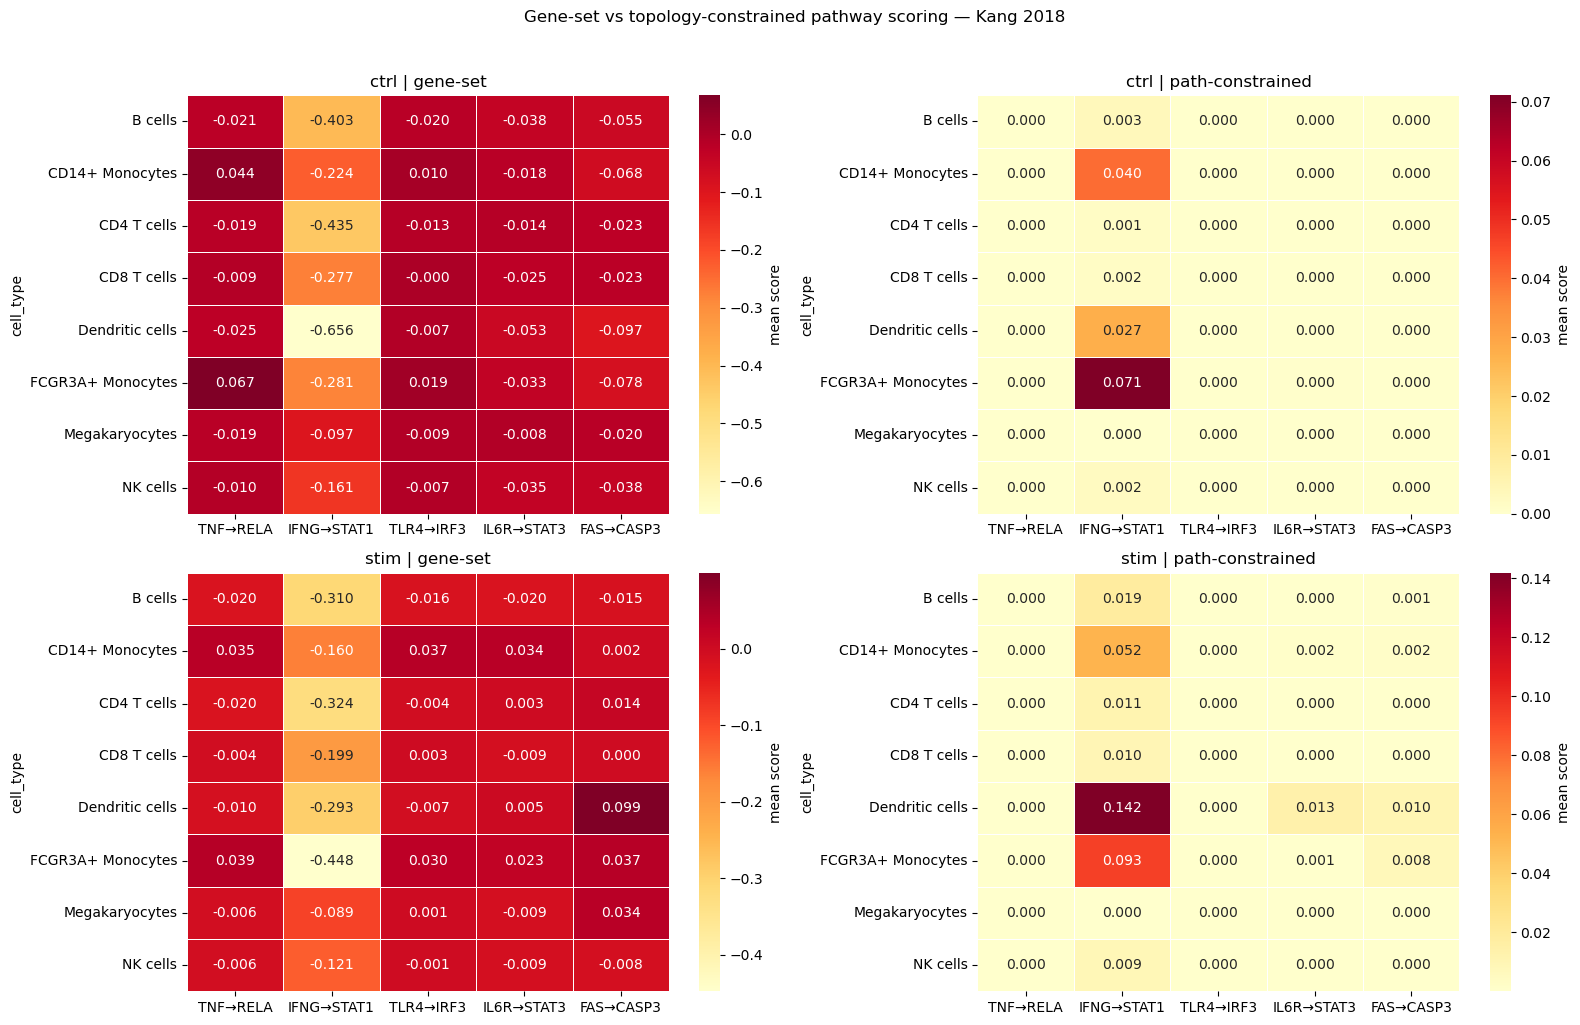

In [15]:
geneset_df = pd.DataFrame(geneset_scores, columns=axis_names)
pathway_df = pd.DataFrame(cell_scores,    columns=axis_names)
for df in (geneset_df, pathway_df):
    df["condition"] = adata.obs["condition"].to_numpy()
    df["cell_type"] = adata.obs["leiden"].to_numpy()

mean_gs   = geneset_df.groupby(["cell_type", "condition"])[axis_names].mean()
mean_path = pathway_df.groupby(["cell_type", "condition"])[axis_names].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for (cond, method, data), ax in zip(
    [("ctrl","gene-set",mean_gs), ("ctrl","path-constrained",mean_path),
     ("stim","gene-set",mean_gs), ("stim","path-constrained",mean_path)],
    axes.flat,
):
    sns.heatmap(
        data.xs(cond, level="condition"),
        ax=ax, cmap="YlOrRd", annot=True, fmt=".3f",
        linewidths=0.5, cbar_kws={"label": "mean score"},
    )
    ax.set_title(f"{cond} | {method}")

plt.suptitle("Gene-set vs topology-constrained pathway scoring — Kang 2018", y=1.02)
plt.tight_layout()
plt.savefig("fig_section6.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 — The Feedback Loop

AnnNet topology results used as AnnData representations. Pathway scores augment the PCA embedding — topology adds signal orthogonal to transcription.

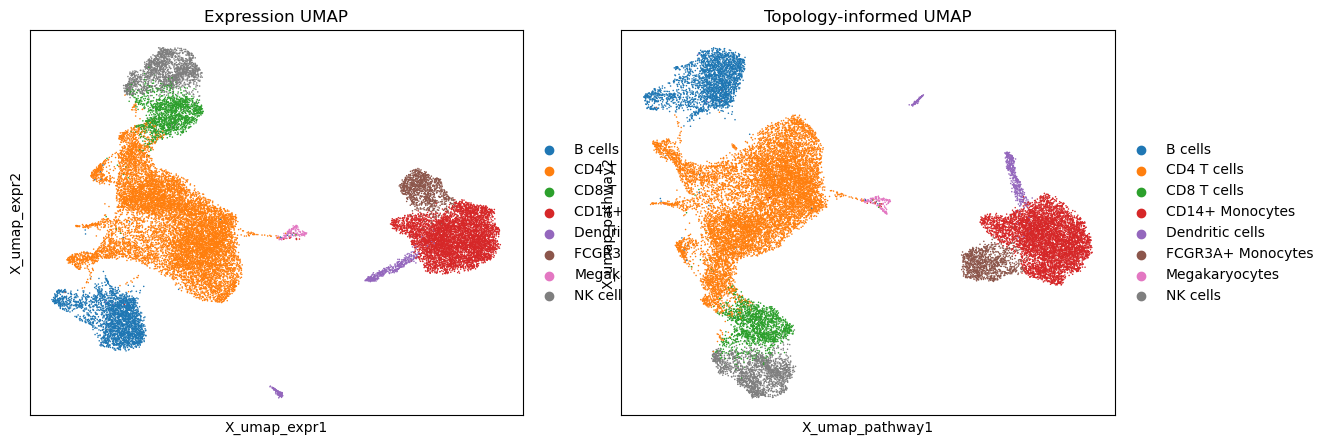

silhouette — expression: 0.344  |  topology-augmented: 0.359


In [16]:
pathway_scaled  = StandardScaler().fit_transform(adata.obsm["X_pathway_scores"])
joint_embedding = np.hstack([adata.obsm["X_pca"], pathway_scaled])
adata.obsm["X_joint"] = joint_embedding

sc.pp.neighbors(adata, use_rep="X_joint", key_added="pathway_neighbors")
sc.tl.umap(adata, neighbors_key="pathway_neighbors")
adata.obsm["X_umap_pathway"] = adata.obsm["X_umap"].copy()

sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)
adata.obsm["X_umap_expr"] = adata.obsm["X_umap"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.embedding(adata, basis="X_umap_expr",    color="leiden", ax=axes[0], show=False, title="Expression UMAP")
sc.pl.embedding(adata, basis="X_umap_pathway", color="leiden", ax=axes[1], show=False, title="Topology-informed UMAP")
plt.savefig("fig_section7.png", dpi=150, bbox_inches="tight")
plt.show()

le     = LabelEncoder()
labels = le.fit_transform(adata.obs["leiden"].values)
sil_expr    = silhouette_score(adata.obsm["X_umap_expr"],    labels, sample_size=5000, random_state=0)
sil_pathway = silhouette_score(adata.obsm["X_umap_pathway"], labels, sample_size=5000, random_state=0)
print(f"silhouette — expression: {sil_expr:.3f}  |  topology-augmented: {sil_pathway:.3f}")

In [17]:
sc.tl.rank_genes_groups(adata, groupby="condition", method="wilcoxon", n_genes=200, use_raw=False)
stim_degs     = set(sc.get.rank_genes_groups_df(adata, group="stim").head(200)["names"].tolist())
stim_network  = set(G.slices.vertices("expressed_stim"))
degs_in_net   = [g for g in stim_degs if g in stim_network]

deg_indegree  = {g: len(G._tgt_to_edges.get(g, [])) for g in degs_in_net}  # INTERNAL API — raise issue for public equivalent
top_downstream = sorted(deg_indegree.items(), key=lambda x: x[1], reverse=True)[:10]

print(f"top-200 stim DEGs in expressed_stim network: {len(degs_in_net)}/200")
print("\ntop 10 by in-degree (most signaling inputs):")
for gene, indeg in top_downstream:
    print(f"  {gene}: {indeg}")
print()
print("These genes are transcriptionally induced (AnnData) and topologically downstream")
print("in the IFN-β network (AnnNet). AnnData identifies that they change; AnnNet")
print("identifies why — they sit at the receiving end of intact signaling cascades.")

top-200 stim DEGs in expressed_stim network: 113/200

top 10 by in-degree (most signaling inputs):
  TRIM22: 138
  HERC6: 136
  HERC5: 136
  RBCK1: 136
  RNF213: 136
  STAT1: 44
  MCL1: 23
  HSP90AA1: 21
  CASP1: 20
  HSPB1: 20

These genes are transcriptionally induced (AnnData) and topologically downstream
in the IFN-β network (AnnNet). AnnData identifies that they change; AnnNet
identifies why — they sit at the receiving end of intact signaling cascades.


## 8 — Write-Back and Serialization

In [18]:
adata.obsm["X_geneset_scores"] = geneset_scores
adata.obsm["X_pathway_scores"]  = cell_scores
adata.uns["pathway_score_names"] = axis_names

var_name_set  = set(adata.var_names)
gene_stat_map = {row["vertex_id"]: (row["mean_expr"], row["var_expr"]) for row in gene_stats_df.iter_rows(named=True)}

G.set_vertex_attrs_bulk({
    v: {
        "mean_expr":  float(gene_stat_map[v][0]) if v in var_name_set else 0.0,
        "var_expr":   float(gene_stat_map[v][1]) if v in var_name_set else 0.0,
        "out_degree": float(len(G._src_to_edges.get(v, []))),  # INTERNAL API — raise issue for public equivalent
    }
    for v in G.vertices()
})

pyg_data = to_pyg(
    G,
    node_features={"default": ["mean_expr", "var_expr", "out_degree"]},
    edge_features={("default", "edge", "default"): ["n_sources", "consensus_stimulation"]},
    slice_id="gained_stim",
)
print(pyg_data)
print("node_types:", pyg_data.node_types)
print("edge_types:", pyg_data.edge_types)

HeteroData(
  manifest={
    node_index={
      default={
        CALM3=0,
        TRPC1=1,
        CALM1=2,
        CALM2=3,
        CAV1=4,
        DRD2=5,
        MDFI=6,
        ITPR2=7,
        MARCKS=8,
        GRM1=9,
        STIM1=10,
        TRPC3=11,
        TRPC4=12,
        TRPC5=13,
        TRPC6=14,
        PKD2=15,
        TRPV4=16,
        TRPV6=17,
        CASR=18,
        EPOR=19,
        HOMER1=20,
        ITPR1=21,
        ITPR3=22,
        ASPH=23,
        ORAI1=24,
        PRKG1=25,
        RNF24=26,
        SRC=27,
        TRPM4=28,
        WNK4=29,
        FYN=30,
        NHERF1=31,
        CABP1=32,
        NCS1=33,
        SESTD1=34,
        MX1=35,
        PRKACA=36,
        SNF8=37,
        TRPC7=38,
        TRPV1=39,
        CNR1=40,
        CDK5=41,
        FAF1=42,
        GABARAP=43,
        KIF13B=44,
        PIRT=45,
        NTRK1=46,
        EGFR=47,
        TRPV3=48,
        HCK=49,
        LCK=50,
        LYN=51,
        MAP7=52,
        OS9=53,
   

In [19]:
G.write("kang2018_omnipath_v2.annnet", overwrite=True)
adata.write_h5ad("kang2018_pathway_scores.h5ad")

G2 = AnnNet.read("kang2018_omnipath_v2.annnet")
print(f"vertices: {G.num_vertices} → {G2.num_vertices} | edges: {G.num_edges} → {G2.num_edges}")
print(f"adata.obsm: {list(adata.obsm.keys())}")

vertices: 8791 → 8791 | edges: 85217 → 85217
adata.obsm: ['X_pca', 'X_umap', 'X_pathway_scores', 'X_joint', 'X_umap_pathway', 'X_umap_expr', 'X_geneset_scores']


## 9 — The Structural Boundary

Everything above could be replicated with NetworkX + pandas, with more boilerplate. This section cannot.

Metabolic reactions are hyperedges: ATP + Glucose → ADP + Glucose-6-phosphate is one stoichiometric event. The sign pattern in a single incidence column encodes which metabolites are substrates (+1) and which are products (−1). In a binary-edge library you must expand each hyperedge into a clique of pairwise edges — the substrate/product distinction is irrecoverably lost in that expansion, and edge count grows as k(k−1)/2 per reaction.

In [20]:
np.random.seed(42)
n_reactions    = 500
reaction_sizes = np.random.choice([3,4,5,6,7,8], size=n_reactions, p=[0.15,0.25,0.30,0.15,0.10,0.05])
metabolite_pool = [f"met_{i:04d}" for i in range(2000)]

H = AnnNet(directed=True)
reaction_records = []

for idx, size in enumerate(reaction_sizes):
    participants = np.random.choice(metabolite_pool, size=int(size), replace=False).tolist()
    n_sub = int(np.random.randint(1, int(size)))
    substrates, products = participants[:n_sub], participants[n_sub:]
    if not products:
        products = [substrates.pop()]
    eid = f"rxn_{idx:04d}"
    H.add_hyperedge(head=substrates, tail=products, edge_id=eid, edge_directed=True, reaction_size=int(size))
    reaction_records.append({"edge_id": eid, "substrates": substrates, "products": products,
                              "participants": participants, "size": int(size)})

annnet_edges = n_reactions
nx_edges     = int(sum(k*(k-1)//2 for k in reaction_sizes))
print(f"AnnNet:             {annnet_edges} hyperedges")
print(f"NetworkX expansion: {nx_edges} binary edges")
print(f"expansion factor:   {nx_edges/annnet_edges:.1f}×")
print(f"at Human-GEM scale (13,000 reactions): ~{int(nx_edges/n_reactions*13000):,} NetworkX edges")

AnnNet:             500 hyperedges
NetworkX expansion: 5383 binary edges
expansion factor:   10.8×
at Human-GEM scale (13,000 reactions): ~139,958 NetworkX edges


In [21]:
expanded_nx = nx.DiGraph()
for r in reaction_records:
    for u in range(len(r["participants"])):
        for v in range(u+1, len(r["participants"])):
            expanded_nx.add_edge(r["participants"][u], r["participants"][v], reaction_id=r["edge_id"])

annnet_csr    = H.X().tocsr()
annnet_memory = deep_sizeof(annnet_csr)
nx_memory     = deep_sizeof(expanded_nx)

ex   = reaction_records[0]
col  = H.edge_to_idx[ex["edge_id"]]
coo  = annnet_csr[:, col].tocoo()
signs = {H.idx_to_entity[r]: int(v) for r, v in zip(coo.row.tolist(), coo.data.tolist())}

print(f"AnnNet incidence matrix:  {annnet_memory/1024:.1f} KiB")
print(f"NetworkX expanded graph:  {nx_memory/1024:.1f} KiB")
print(f"memory ratio:             {nx_memory/annnet_memory:.1f}×")
print()
print(f"example — {ex['edge_id']}")
print(f"  substrates: {ex['substrates']}")
print(f"  products:   {ex['products']}")
print(f"  incidence signs: {signs}")
print()
print("The pairwise binary edges carry no substrate/product information.")
print("The incidence column does. This is not a performance difference but a representational one.")

AnnNet incidence matrix:  8.9 KiB
NetworkX expanded graph:  1924.0 KiB
memory ratio:             215.3×

example — rxn_0000
  substrates: ['met_1179', 'met_1601']
  products:   ['met_0495', 'met_1655']
  incidence signs: {'met_1179': 1, 'met_1601': 1, 'met_0495': -1, 'met_1655': -1}

The pairwise binary edges carry no substrate/product information.
The incidence column does. This is not a performance difference but a representational one.
